# Section 4: Inference of state field physics

Companion notebook for Section 4 of **"Statistical physics of language change inferred from time evolving maps"** (Burridge & Vaux).

**Goal:** infer the model parameters $(\beta, \mathbf{s})$ by minimising the discrepancy between empirical MAP field increments and those predicted by the state field model.

**Prerequisites:** this notebook uses
- Pre-computed MAP fields from Section 2 (`data/probability_fields/`)
- Migration generator $W$ and copying generator $L$ from Section 3 (`spatial_model.py`)

**Key outputs:**
- Figure 7: roly MAP fields and inferred bias fields (η = 1000 km) by decade
- Figure 8: devil MAP fields and inferred bias fields by decade
- Figure 9: KL divergence vs. bias field complexity η for soda/pop/coke
- Figure 10: soda/pop/coke forward predictions
- Figure 11: accommodation factor β and biases over time for all six variables

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

import glob
import importlib

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.spatial import distance_matrix
from scipy.optimize import minimize

import spatial_model as sm
import model_inference as mif

importlib.reload(sm)   # picks up any changes to spatial_model.py

<module 'spatial_model' from 'C:\\Users\\james\\Dropbox\\RESEARCH\\APEX_2024\\REPO\\code\\src\\spatial_model.py'>

In [7]:
# Paths — notebook lives in code/state_field_model/
repo_root   = Path().resolve().parents[1]
voronoi_dir = repo_root / 'data' / 'voronois'
p_field_dir = repo_root / 'data' / 'probability_fields'
fig_dir     = repo_root / 'figures'

cmap       = 'RdYlBu_r'
n_demes    = 4000
start_year = 1950
end_year   = 2000
J          = 0.1    # copying rate (fixed, see Section 3)

In [8]:
# Load Voronoi tessellation
gdf_voronoi = gpd.read_file(voronoi_dir / f'Voronoi_{n_demes}_raw_kmeans_demes.gpkg')
DX   = np.column_stack([gdf_voronoi.x.values, gdf_voronoi.y.values])
dmat = distance_matrix(DX, DX) / 1e3
pops = gdf_voronoi['pop'].values
N    = len(pops)
print(f'N = {N} cells')

N = 4000 cells


In [9]:
# Build migration generator W and copying generator L
# (same parameters as Section 3 — may take ~2 min each)
d0, gamma0, gamma1, alpha_mig, lambda_bar = 48.91, 5.57, -0.35, 0.60, 0.063
R = 100   # copying range (km)

c = sm.get_c(pops, dmat, d0, gamma0, gamma1, alpha_mig, lambda_bar)

print('Building W ...')
W = sm.migration_generator(dmat, pops, d0, gamma0, gamma1, alpha_mig, c)
print('Building L ...')
L = sm.diffusion_generator(dmat, pops, R)
print('Done.')

Building W ...
Building L ...
Done.


In [10]:
# Load all six v_4 MAP probability fields
v4_files = sorted(glob.glob(str(p_field_dir / 'v_4_*.npy')))

variables = {}
for f in v4_files:
    P     = np.load(f)
    K     = P.shape[2]
    parts = Path(f).stem.split('_')
    key   = '_'.join(parts[2:2 + K])
    variables[key] = {'P': P, 'K': K, 'variants': parts[2:2 + K]}

for key, v in variables.items():
    print(f'{key:40s}  shape {v["P"].shape}')

crawfish_crayfish_crawdad                 shape (4000, 51, 3)
roly_bug                                  shape (4000, 51, 2)
soda_pop_coke                             shape (4000, 51, 3)
sunshower_devil                           shape (4000, 51, 2)
tennis_sneakers                           shape (4000, 51, 2)
you-guys_you-all                          shape (4000, 51, 2)


## §4: Inference framework

We infer model parameters by assuming that MAP field increments $\delta\hat{X}_i(t)$ can be written as (eq. 4.1)
$$\delta\hat{X}_i(t) = \mathbf{b}_i(\hat{X}(t);\boldsymbol{\theta})\,\delta t + \delta\boldsymbol{\mathcal{E}}_i(t)$$
where $\mathbf{b}_i$ is the drift function and $\boldsymbol{\mathcal{E}}_i$ is a residual with $\mathbb{E}(\delta\boldsymbol{\mathcal{E}}_i) \approx 0$. We find $\boldsymbol{\theta}$ by minimising the regularised mean-squared residual
$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \left[\frac{1}{NT}\sum_{i,t}\left\|\delta\hat{X}_i(t) - \mathbf{b}_i(\hat{X}(t);\boldsymbol{\theta})\,\delta t\right\|^2 + \gamma\,\overline{s^2}\right]$$
with $\gamma \approx 10^{-4}$ and $\overline{s^2} = \frac{1}{NK}\sum_{i,k}s_{ik}^2$ the mean squared bias field.

### §4(a): Interface stability condition

For a two-variant system in 1D with uniform bias $s$ and accommodation $\beta$, the condition for spatial variation to persist against migration is
$$\beta > 2\lambda \approx 0.12$$
and the stable interface width is
$$w = \sqrt{\frac{D}{\beta - 2\lambda}}, \qquad D = \frac{JR^2}{2}$$
Using $\beta = 0.2$, $\lambda = 0.063$, $J = 0.1$, $R = 100$ km gives $w \approx 82$ km — about two cell diameters.

In [11]:
# Interface width formula (§4(a), eq. 4.3)
beta_typ = 0.20
lam      = lambda_bar
D        = J * R**2 / 2
w        = np.sqrt(D / (beta_typ - 2 * lam))
R_cell   = np.sqrt(8.08e6 / (n_demes * np.pi))   # mean cell radius (km), USA area ≈ 8.08×10⁶ km²
print(f'D = JR²/2 = {D:.0f} km²')
print(f'Interface width w = {w:.0f} km  (~{w/R_cell:.1f} cell diameters)')

D = JR²/2 = 500 km²
Interface width w = 82 km  (~3.2 cell diameters)


## §4(c): Time evolution of parameters — scalar bias

We fit a spatially uniform (scalar) bias vector $\mathbf{s}$ and accommodation factor $\beta$ using a sliding decade-long window of MAP fields. This gives Figure 11, showing that $\beta \approx 0.2$ is remarkably consistent across all variables and throughout the study period.

In [12]:
T_window  = 10
t0s       = np.arange(0, end_year - start_year - T_window + 1, T_window)
mid_years = start_year + t0s + T_window // 2

scalar_results = {}

for key, var in variables.items():
    P = var['P']
    K = var['K']
    betas, biases = [], []
    for t0 in t0s:
        t1  = t0 + T_window
        obj = sm.make_objective(P, W, L, t0, t1, J)
        res = minimize(obj, np.zeros(K + 1))          # default BFGS, matching original
        betas.append(res.x[0])
        biases.append(res.x[1:])
        print(f'  {key}  {1950+t0}-{1950+t1}  β={res.x[0]:.3f}  s={res.x[1:].round(3)}')
    scalar_results[key] = {'beta': np.array(betas), 'biases': np.array(biases)}

  crawfish_crayfish_crawdad  1950-1960  β=0.261  s=[-0.016  0.002  0.014]
  crawfish_crayfish_crawdad  1960-1970  β=0.238  s=[-0.007 -0.007  0.013]
  crawfish_crayfish_crawdad  1970-1980  β=0.226  s=[-0.009  0.002  0.007]
  crawfish_crayfish_crawdad  1980-1990  β=0.219  s=[-0.022  0.02   0.002]
  crawfish_crayfish_crawdad  1990-2000  β=0.209  s=[-0.033  0.028  0.006]
  roly_bug  1950-1960  β=0.191  s=[-0.004  0.004]
  roly_bug  1960-1970  β=0.210  s=[-0.002  0.002]
  roly_bug  1970-1980  β=0.197  s=[-0.002  0.002]
  roly_bug  1980-1990  β=0.159  s=[-0.002  0.002]
  roly_bug  1990-2000  β=0.114  s=[-0.004  0.004]
  soda_pop_coke  1950-1960  β=0.215  s=[-0.026  0.005  0.021]
  soda_pop_coke  1960-1970  β=0.209  s=[-0.021  0.011  0.01 ]
  soda_pop_coke  1970-1980  β=0.209  s=[-0.018  0.02  -0.001]
  soda_pop_coke  1980-1990  β=0.211  s=[-0.021  0.026 -0.005]
  soda_pop_coke  1990-2000  β=0.215  s=[-0.032  0.026  0.006]
  sunshower_devil  1950-1960  β=0.185  s=[-0.015  0.015]
  sunshower_d

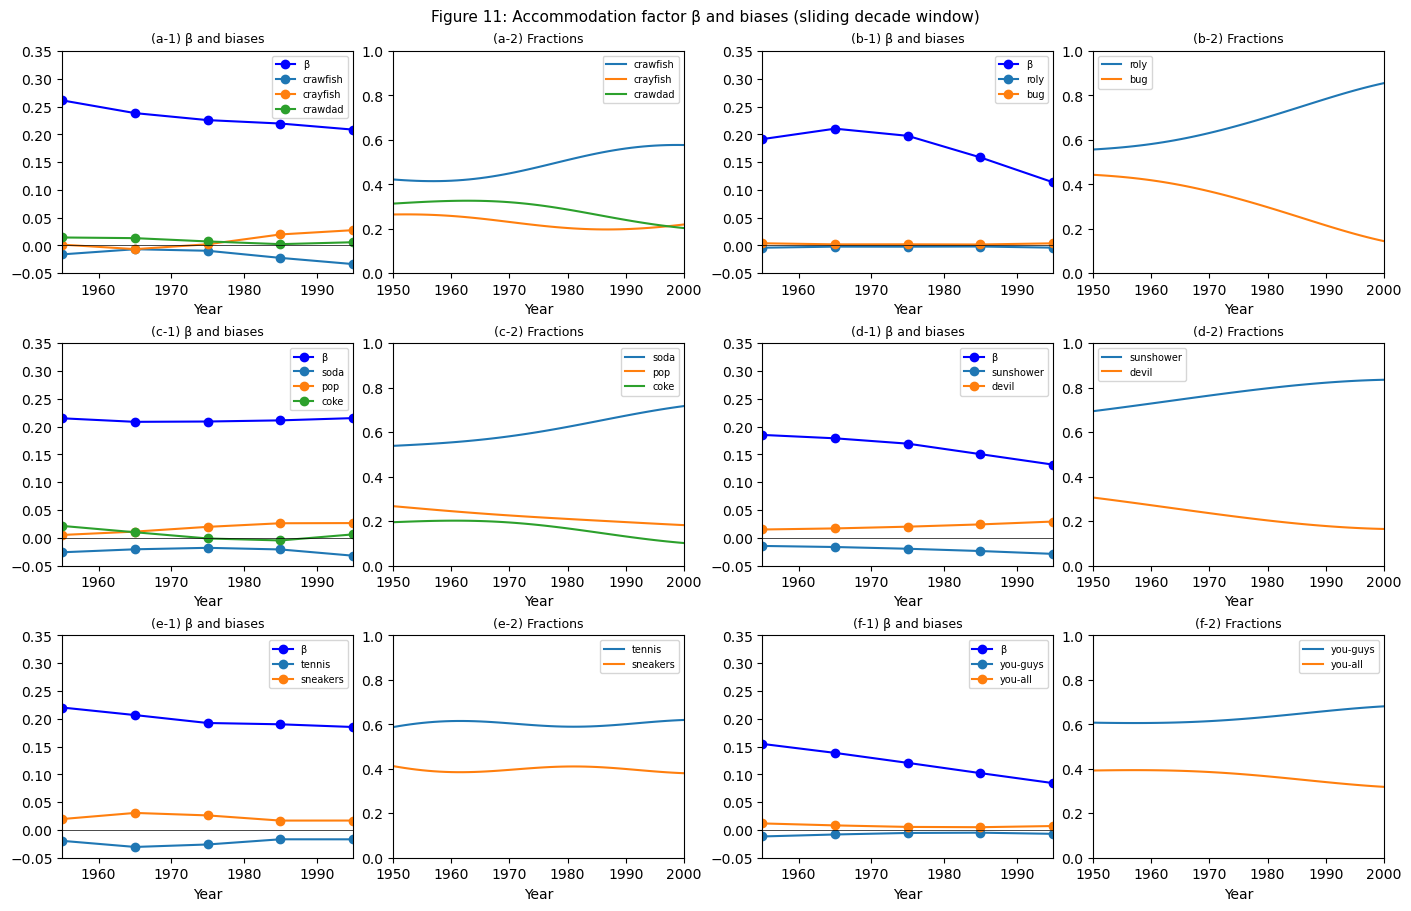

In [13]:
# Figure 11: β and biases over time for all six variables
fig, axs = plt.subplots(3, 4, figsize=(14, 9), constrained_layout=True)

for row, (key, var) in enumerate(variables.items()):
    res     = scalar_results[key]
    variant_labels = var['variants']
    K       = var['K']

    # β panel
    ax_beta = axs[row // 2, (row % 2) * 2]
    ax_beta.plot(mid_years, res['beta'], 'b-o', label='β')
    for k in range(K):
        ax_beta.plot(mid_years, res['biases'][:, k], '-o', label=variant_labels[k])
    ax_beta.axhline(0, color='k', lw=0.5)
    ax_beta.set_xlim(1955, 1995)
    ax_beta.set_ylim(-0.05, 0.35)
    ax_beta.set_title(f'({chr(97 + row)}-1) β and biases', fontsize=9)
    ax_beta.legend(fontsize=7)
    ax_beta.set_xlabel('Year')

    # National fraction panel
    P = var['P']
    national_frac = (P * pops[:, None, None]).sum(axis=0) / pops.sum()  # (T, K)
    ax_frac = axs[row // 2, (row % 2) * 2 + 1]
    years_all = np.arange(start_year, end_year + 1)
    for k in range(K):
        ax_frac.plot(years_all, national_frac[:, k], label=variant_labels[k])
    ax_frac.set_xlim(start_year, end_year)
    ax_frac.set_ylim(0, 1)
    ax_frac.set_title(f'({chr(97 + row)}-2) Fractions', fontsize=9)
    ax_frac.legend(fontsize=7)
    ax_frac.set_xlabel('Year')

plt.suptitle('Figure 11: Accommodation factor β and biases (sliding decade window)', fontsize=11)
plt.savefig(fig_dir / 'param_evo.png', dpi=300, bbox_inches='tight')
plt.show()

## §4(b): Spatial bias field

To allow the bias to vary in space we write $\mathbf{S} = A\boldsymbol{\Psi}$ where $A \in \mathbb{R}^{N \times Q}$ is the **lifting matrix** — the first $Q$ eigenvectors of the degree-normalised Gram matrix
$$G_{ij} = \exp\!\left(-\frac{\|\mathbf{r}_i - \mathbf{r}_j\|^2}{2\eta^2}\right)$$
The parameter $\eta$ (km) controls the minimum spatial complexity of the inferred bias field. $Q$ is chosen so that the first $Q$ eigenvectors explain fraction $R^2_{\min} = 0.99$ of variance in a random field with length scale $\eta$.

For Figures 7 and 8 we use $\eta = 1000$ km. The optimal $\eta$ for forecasting is determined by cross-validation (Figure 9).

In [14]:
# Build lifting matrix A for η = 1000 km (Figures 7/8)
eta  = 1000
Rmin = 0.99
A, Q, varexp = mif.simple_basis(eta, dmat, Rmin)
print(f'η = {eta} km  →  Q = {Q} basis vectors  (variance explained = {varexp[Q-1]:.4f})')

η = 1000 km  →  Q = 13 basis vectors  (variance explained = 0.9916)


In [15]:
# Fit spatial bias for roly/bug and sunshower/devil over sliding decade windows

spatial_results = {}

for key in ['roly_bug', 'sunshower_devil']:
    var = variables[key]
    P   = var['P']
    K   = var['K']
    betas, bias_fields, psys = [], [], []

    for t0 in t0s:
        t1   = t0 + T_window
        obj  = sm.make_spatial_bias_objective(P, W, L, A, J, t0, t1)
        res  = minimize(obj, np.zeros(1 + Q * K))     # default BFGS, matching original
        beta = res.x[0]
        psi  = res.x[1:].reshape(Q, K)
        s    = A @ psi
        betas.append(beta)
        bias_fields.append(s)
        psys.append(psi)
        print(f'  {key}  {1950+t0}-{1950+t1}  β={beta:.3f}  mean|s|={np.mean(np.abs(s)):.4f}')

    spatial_results[key] = {
        'beta':        np.array(betas),
        'bias_fields': np.array(bias_fields),
        'psi':         np.array(psys),
    }

  roly_bug  1950-1960  β=0.205  mean|s|=0.0123
  roly_bug  1960-1970  β=0.213  mean|s|=0.0094
  roly_bug  1970-1980  β=0.200  mean|s|=0.0068
  roly_bug  1980-1990  β=0.153  mean|s|=0.0000
  roly_bug  1990-2000  β=0.109  mean|s|=0.0062
  sunshower_devil  1950-1960  β=0.166  mean|s|=0.0109
  sunshower_devil  1960-1970  β=0.153  mean|s|=0.0108
  sunshower_devil  1970-1980  β=0.133  mean|s|=0.0104
  sunshower_devil  1980-1990  β=0.104  mean|s|=0.0101
  sunshower_devil  1990-2000  β=0.064  mean|s|=0.0096


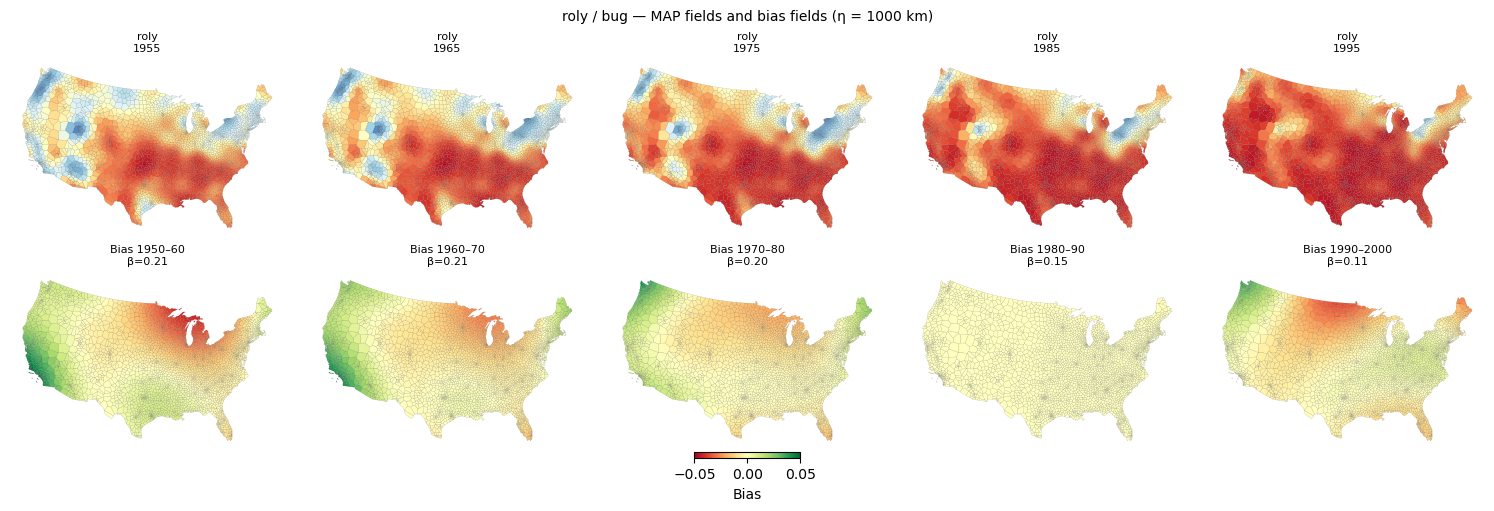

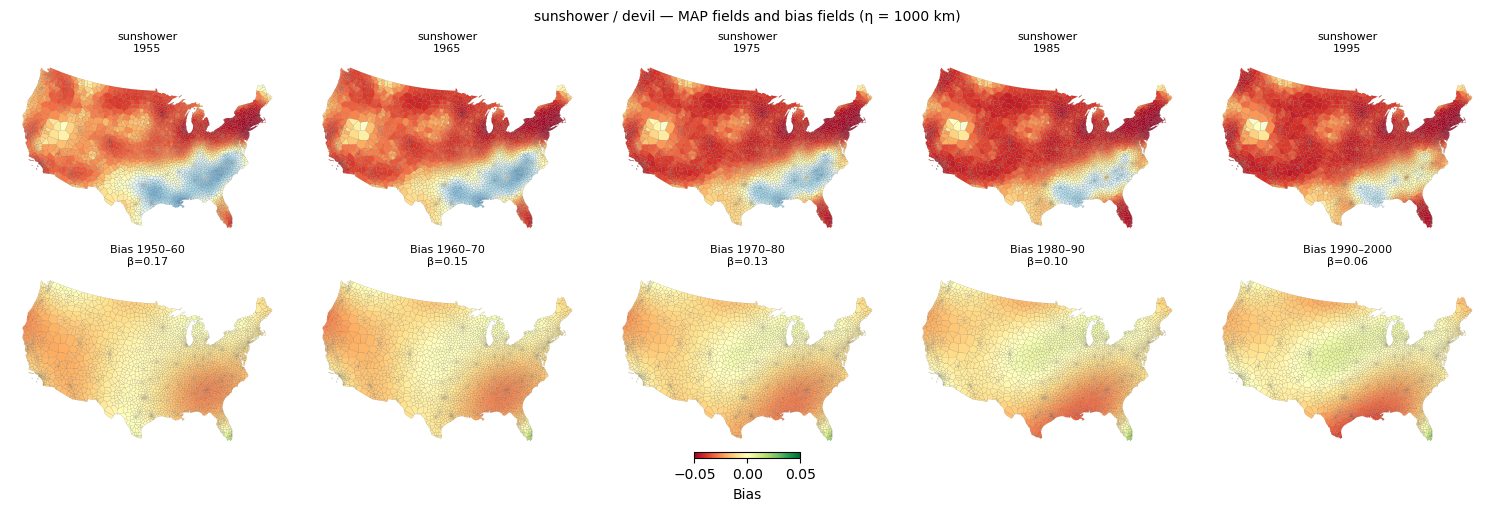

In [16]:
# Figures 7 and 8: MAP fields + bias fields by decade
decade_labels = ['1950–60', '1960–70', '1970–80', '1980–90', '1990–2000']
mid_t = t0s + T_window // 2    # mid-decade time indices

for key in ['roly_bug', 'sunshower_devil']:
    var      = variables[key]
    P        = var['P']
    res      = spatial_results[key]
    variant0 = var['variants'][0]   # first variant to plot
    n_dec    = len(t0s)

    fig, axs = plt.subplots(2, n_dec, figsize=(3 * n_dec, 5), constrained_layout=True)

    for col, (t_mid, dlabel) in enumerate(zip(mid_t, decade_labels)):
        # Top row: MAP state field at mid-decade
        gdf_voronoi.plot(
            column=P[:, t_mid, 0], ax=axs[0, col],
            cmap=cmap, vmin=0, vmax=1, linewidth=0.05, edgecolor='k'
        )
        axs[0, col].set_axis_off()
        axs[0, col].set_title(f'{variant0}\n{1950 + t_mid}', fontsize=8)

        # Bottom row: inferred bias field s[:,0] for that decade
        s_decade = res['bias_fields'][col, :, 0]
        clim = 0.05
        gdf_voronoi.plot(
            column=s_decade, ax=axs[1, col],
            cmap='RdYlGn', vmin=-clim, vmax=clim, linewidth=0.05, edgecolor='k'
        )
        axs[1, col].set_axis_off()
        axs[1, col].set_title(f'Bias {dlabel}\nβ={res["beta"][col]:.2f}', fontsize=8)

    fig.colorbar(
        plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(-clim, clim)),
        ax=axs[1, :], orientation='horizontal', fraction=0.03, pad=0.02, label='Bias'
    )
    fig_name = 'roly_bug' if key == 'roly_bug' else 'sunshower_devil'
    plt.suptitle(f'{key.replace("_", " / ")} — MAP fields and bias fields (η = {eta} km)', fontsize=10)
    plt.savefig(fig_dir / f'{fig_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

## §4(b): Forward predictions — Figure 10

We assess the model's forecasting ability by fitting parameters to a training decade and then evolving the model forward in time. Model predictions are compared to MAP fields via the cell-averaged KL divergence
$$D_{\mathrm{KL}}(\hat{x}_i^{\mathrm{MAP}}(t)\,\|\,\hat{x}_i^{\mathrm{pred}}(t)) = \sum_k \hat{x}_{ik}^{\mathrm{MAP}}\log\frac{\hat{x}_{ik}^{\mathrm{MAP}}}{\hat{x}_{ik}^{\mathrm{pred}}}$$

Figure 10 shows predictions for soda/pop/coke using training interval [1975, 1985] and $\eta = 2000$ km.

In [17]:
# Figure 10: forward predictions for soda/pop/coke
key    = 'soda_pop_coke'
var    = variables[key]
P_soda = var['P']
K_soda = var['K']

eta_pred = 2000
A_pred, Q_pred, _ = mif.simple_basis(eta_pred, dmat, Rmin)
print(f'η = {eta_pred} km  →  Q = {Q_pred} basis vectors')

t_train0, t_train1 = 25, 35
obj  = sm.make_spatial_bias_objective(P_soda, W, L, A_pred, J, t_train0, t_train1)
res  = minimize(obj, np.zeros(1 + Q_pred * K_soda))  # default BFGS
beta_pred = res.x[0]
psi_pred  = res.x[1:].reshape(Q_pred, K_soda)
s_pred    = A_pred @ psi_pred
print(f'Fitted β = {beta_pred:.3f},  mean|s| = {np.mean(np.abs(s_pred)):.4f}')

T_fwd     = (end_year - start_year) - t_train1
X0_pred   = P_soda[:, t_train1, :].copy()
mod_pred  = sm.model(W, L, J, s_pred, beta_pred, X0_pred)
xsol_pred = mod_pred.solve(np.arange(T_fwd + 1))

η = 2000 km  →  Q = 6 basis vectors
Fitted β = 0.255,  mean|s| = 0.0235


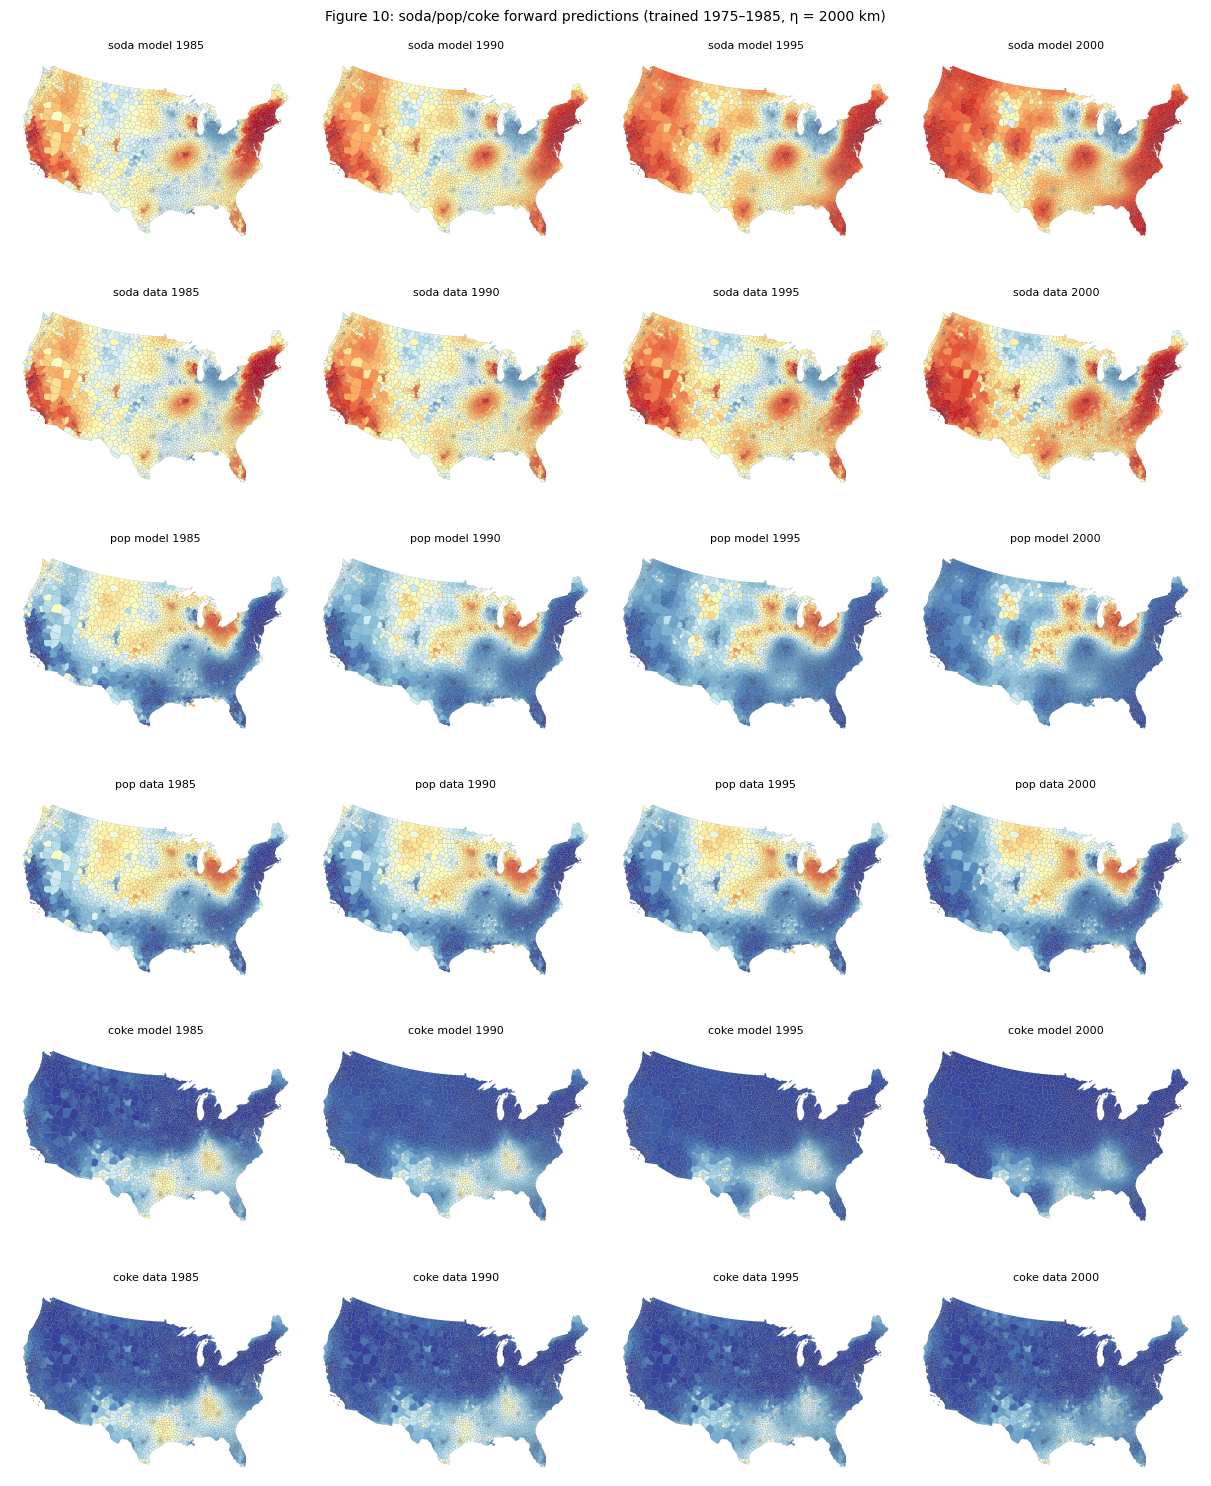

In [18]:
# Plot Figure 10: model vs. MAP for each variant, four time slices
plot_years = [1985, 1990, 1995, 2000]
n_rows     = 2 * K_soda

fig, axs = plt.subplots(n_rows, len(plot_years), figsize=(12, 2.5 * n_rows), constrained_layout=True)

for col, yr in enumerate(plot_years):
    t_emp = yr - start_year
    t_mod = yr - (start_year + t_train1)
    for k in range(K_soda):
        # Model row
        ax_mod = axs[2 * k, col]
        gdf_voronoi.plot(column=xsol_pred[t_mod, :, k], ax=ax_mod,
                         cmap=cmap, vmin=0, vmax=1, linewidth=0.05, edgecolor='k')
        ax_mod.set_axis_off()
        ax_mod.set_title(f'{var["variants"][k]} model {yr}', fontsize=8)

        # Empirical (MAP) row
        ax_emp = axs[2 * k + 1, col]
        gdf_voronoi.plot(column=P_soda[:, t_emp, k], ax=ax_emp,
                         cmap=cmap, vmin=0, vmax=1, linewidth=0.05, edgecolor='k')
        ax_emp.set_axis_off()
        ax_emp.set_title(f'{var["variants"][k]} data {yr}', fontsize=8)

plt.suptitle(f'Figure 10: soda/pop/coke forward predictions (trained 1975–1985, η = {eta_pred} km)', fontsize=10)
plt.savefig(fig_dir / 'soda_pop_coke_KLD.png', dpi=300, bbox_inches='tight')
plt.show()

## §4(b): Forecasting skill vs. forecast horizon

We assess how well the spatial bias model predicts the future evolution of language change by comparing forward model predictions against MAP fields via the cell-averaged KL divergence
$$D_{\mathrm{KL}}(\hat{x}_i^{\mathrm{MAP}}(t)\,\|\,\hat{x}_i^{\mathrm{pred}}(t)) = \sum_k \hat{x}_{ik}^{\mathrm{MAP}}\log\frac{\hat{x}_{ik}^{\mathrm{MAP}}}{\hat{x}_{ik}^{\mathrm{pred}}}$$
averaged over all demes $i$.

For each variable we fit parameters on a sliding 10-year calibration window (windows starting at $t_0 \in \{1950, 1955, 1960, 1965\}$) and then evolve the model forward for up to 25 years, computing KLD at each year. Results are averaged over calibration windows; shaded bands show ±1 standard deviation across windows.

We compare three model classes:
- **s = 0** (dashed): accommodation only, no spatial bias (β fitted, s ≡ 0)
- **Scalar bias** (dotted): spatially uniform bias vector fitted per variant
- **Spatial bias** (coloured): spatially varying bias field with length scale η ∈ {400, 800, 1600} km

If the spatial bias improves long-range forecasting, the coloured curves should fall below the baselines at large forecast horizons.

In [19]:
# Shared parameters for forecast horizon analysis
etas_kld    = [400, 800, 1600]
T_calib_kld = 10
T_fwd_kld   = 25
t_step_kld  = 5
REG_kld     = 1e-4
Rmin_kld    = 0.99

pred_years = np.arange(1, T_fwd_kld)   # [1, 2, ..., 24] — skip t=0 (initial condition)

colors_eta = {400: '#e41a1c', 800: '#377eb8', 1600: '#4daf4a'}

In [20]:
# Grid KLD calculations — stores results in all_kld_results for replotting

var_order = [
    ('crawfish_crayfish_crawdad', 'crawfish / crayfish / crawdad'),
    ('roly_bug',                  'roly / bug'),
    ('soda_pop_coke',             'soda / pop / coke'),
    ('sunshower_devil',           'sunshower / devil'),
    ('tennis_sneakers',           'tennis / sneakers'),
    ('you-guys_you-all',          'you-guys / you-all'),
]

all_kld_results = {}   # keyed by variable key

for idx, (key, label) in enumerate(var_order):
    P_v = variables[key]['P']
    K_v = variables[key]['K']
    print(f'\n({chr(97+idx)}) {label}  K={K_v}')
    res_v = {}

    # baseline 1: s=0, β fitted
    kld_null_v = []
    t0 = 0
    while t0 + T_calib_kld + T_fwd_kld <= end_year - start_year:
        t1 = t0 + T_calib_kld;  t2 = t1 + T_fwd_kld
        obj_f  = sm.make_objective(P_v, W, L, t0, t1, J)
        beta_n = minimize(lambda b: obj_f(np.concatenate([b, np.zeros(K_v)])), [0.2]).x[0]
        mod    = sm.model(W, L, J, np.zeros((N, K_v)), beta_n, P_v[:, t1, :].copy())
        xsol   = mod.solve(np.arange(T_fwd_kld + 1))
        kld_null_v.append(sm.kld_time_series(P_v[:, t1:t2, :],
                                              xsol.transpose(1, 0, 2)[:, :T_fwd_kld, :]))
        t0 += t_step_kld
    res_v['null'] = np.array(kld_null_v)

    # baseline 2: scalar bias
    kld_sc_v = []
    t0 = 0
    while t0 + T_calib_kld + T_fwd_kld <= end_year - start_year:
        t1 = t0 + T_calib_kld;  t2 = t1 + T_fwd_kld
        res_sc  = minimize(sm.make_objective(P_v, W, L, t0, t1, J), np.zeros(1 + K_v))
        beta_sc = res_sc.x[0];  s_sc = res_sc.x[1:]
        mod     = sm.model(W, L, J, np.tile(s_sc, (N, 1)), beta_sc, P_v[:, t1, :].copy())
        xsol    = mod.solve(np.arange(T_fwd_kld + 1))
        kld_sc_v.append(sm.kld_time_series(P_v[:, t1:t2, :],
                                            xsol.transpose(1, 0, 2)[:, :T_fwd_kld, :]))
        t0 += t_step_kld
    res_v['scalar'] = np.array(kld_sc_v)

    # spatial bias curves
    res_v['spatial'] = {}
    for eta_k in etas_kld:
        A_k, Q_k, _ = mif.simple_basis(eta_k, dmat, Rmin_kld)
        kld_windows = []
        t0 = 0
        while t0 + T_calib_kld + T_fwd_kld <= end_year - start_year:
            t1 = t0 + T_calib_kld;  t2 = t1 + T_fwd_kld
            obj  = sm.make_spatial_bias_objective(P_v, W, L, A_k, J, t0, t1, reg=REG_kld)
            res  = minimize(obj, np.zeros(1 + Q_k * K_v))
            beta = res.x[0];  s = A_k @ res.x[1:].reshape(Q_k, K_v)
            print(f'  eta={eta_k} t0={t0}  beta={beta:.3f}  mean|s|={np.mean(np.abs(s)):.4f}')
            mod  = sm.model(W, L, J, s, beta, P_v[:, t1, :].copy())
            xsol = mod.solve(np.arange(T_fwd_kld + 1))
            kld_windows.append(sm.kld_time_series(P_v[:, t1:t2, :],
                                                   xsol.transpose(1, 0, 2)[:, :T_fwd_kld, :]))
            t0 += t_step_kld
        res_v['spatial'][eta_k] = np.array(kld_windows)

    all_kld_results[key] = res_v

print('\nAll calculations done.')


(a) crawfish / crayfish / crawdad  K=3
  eta=400 t0=0  beta=0.305  mean|s|=0.0123
  eta=400 t0=5  beta=0.301  mean|s|=0.0114
  eta=400 t0=10  beta=0.293  mean|s|=0.0116
  eta=400 t0=15  beta=0.285  mean|s|=0.0118
  eta=800 t0=0  beta=0.294  mean|s|=0.0115
  eta=800 t0=5  beta=0.293  mean|s|=0.0101
  eta=800 t0=10  beta=0.286  mean|s|=0.0099
  eta=800 t0=15  beta=0.277  mean|s|=0.0097
  eta=1600 t0=0  beta=0.276  mean|s|=0.0099
  eta=1600 t0=5  beta=0.276  mean|s|=0.0083
  eta=1600 t0=10  beta=0.269  mean|s|=0.0081
  eta=1600 t0=15  beta=0.261  mean|s|=0.0081

(b) roly / bug  K=2
  eta=400 t0=0  beta=0.204  mean|s|=0.0129
  eta=400 t0=5  beta=0.212  mean|s|=0.0121
  eta=400 t0=10  beta=0.214  mean|s|=0.0112
  eta=400 t0=15  beta=0.211  mean|s|=0.0108
  eta=800 t0=0  beta=0.204  mean|s|=0.0121
  eta=800 t0=5  beta=0.212  mean|s|=0.0109
  eta=800 t0=10  beta=0.214  mean|s|=0.0095
  eta=800 t0=15  beta=0.210  mean|s|=0.0086
  eta=1600 t0=0  beta=0.207  mean|s|=0.0129
  eta=1600 t0=5  beta

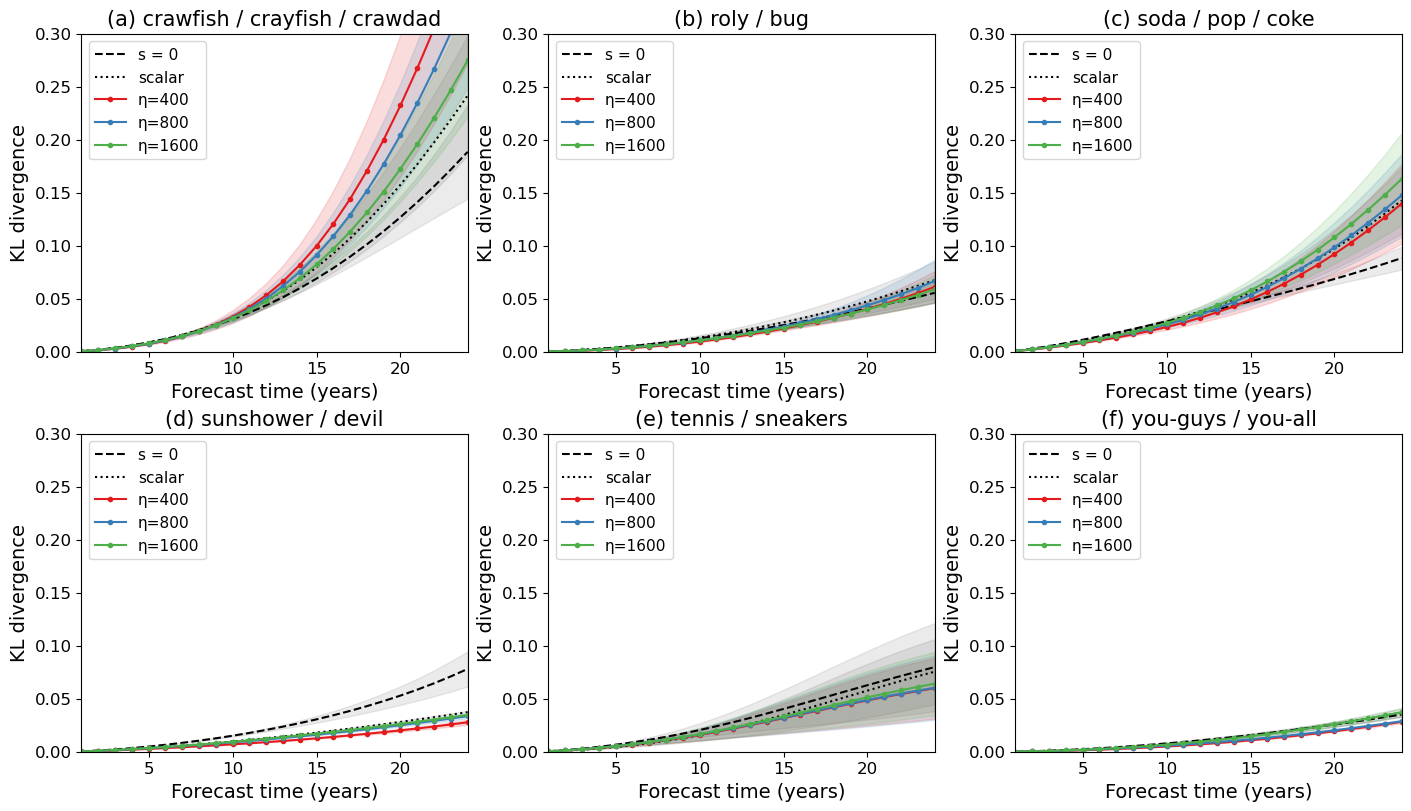

In [21]:
# Plot grid — rerun this cell freely without recomputing

fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for idx, (key, label) in enumerate(var_order):
    ax  = axs[idx // 3, idx % 3]
    res = all_kld_results[key]

    m, e = res['null'][:, 1:].mean(axis=0), res['null'][:, 1:].std(axis=0)
    ax.plot(pred_years, m, 'k--', label='s = 0', linewidth=1.5)
    ax.fill_between(pred_years, m - e, m + e, color='k', alpha=0.08)

    m, e = res['scalar'][:, 1:].mean(axis=0), res['scalar'][:, 1:].std(axis=0)
    ax.plot(pred_years, m, 'k:', label='scalar', linewidth=1.5)
    ax.fill_between(pred_years, m - e, m + e, color='k', alpha=0.08)

    for eta_k in etas_kld:
        arr = res['spatial'][eta_k]
        m   = arr[:, 1:].mean(axis=0)
        e   = arr[:, 1:].std(axis=0)
        c   = colors_eta[eta_k]
        ax.plot(pred_years, m, '-o', color=c, label=f'η={eta_k}', markersize=3)
        ax.fill_between(pred_years, m - e, m + e, color=c, alpha=0.15)

    ax.set_title(f'({chr(97 + idx)}) {label}', fontsize=15)
    ax.set_ylim(0, 0.3)
    ax.set_xlim(1, T_fwd_kld - 1)
    ax.set_xlabel('Forecast time (years)', fontsize=14)
    ax.set_ylabel('KL divergence', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, loc='upper left')

plt.savefig(fig_dir / 'kld_vs_time_all_variables.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# KLD for soda/pop/coke trained 1975-1985, forecast to 2000
# Uses xsol_pred and P_soda already computed in the Figure 10 cell (eta=2000 km)

t_train1_fig10 = 35   # 1985 in index space
T_fwd_fig10    = end_year - start_year - t_train1_fig10   # 15 years

X_true_fig10 = P_soda[:, t_train1_fig10 : t_train1_fig10 + T_fwd_fig10, :]
X_pred_fig10 = xsol_pred.transpose(1, 0, 2)[:, :T_fwd_fig10, :]

kld_fig10 = sm.kld_time_series(X_true_fig10, X_pred_fig10)

print('Year   KLD')
for t in range(T_fwd_fig10):
    print(f'{1985 + t + 1}   {kld_fig10[t]:.5f}')

print(f'\nKLD at 2000 (15-year forecast): {kld_fig10[T_fwd_fig10 - 1]:.5f}')

Year   KLD
1986   0.00000
1987   0.00067
1988   0.00203
1989   0.00373
1990   0.00565
1991   0.00776
1992   0.01004
1993   0.01252
1994   0.01519
1995   0.01809
1996   0.02122
1997   0.02461
1998   0.02829
1999   0.03229
2000   0.03662

KLD at 2000 (15-year forecast): 0.03662
